#  Credit Card Fraud Detection using Machine Learning

###  Objective
Build a machine learning model to detect fraudulent credit card transactions using imbalanced data.

###  Tools Used
- Python (Pandas, NumPy)
- Visualization (Matplotlib, Seaborn)
- Machine Learning (Scikit-learn)

###  Dataset
Credit card transaction dataset (highly imbalanced with fraud cases <1%).

---------

This section imports all the necessary libraries for data handling, visualization, and machine learning.

- Pandas & NumPy → data manipulation  
- Matplotlib & Seaborn → data visualization  
- Scikit-learn → model building and evaluation  

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

%matplotlib inline

## Loading the Dataset

The dataset is loaded into a pandas DataFrame.  
We inspect the shape and preview the first few rows to understand its structure.

In [2]:
df = pd.read_csv("creditcard.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

Dataset loaded successfully!
Shape: (284807, 31)

First 5 rows:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0

## Exploratory Data Analysis (EDA)

We explore the dataset to understand:
- Data types and structure
- Statistical distribution of features
- Class imbalance (fraud vs normal transactions)

This step is important to understand the nature of the data before modeling.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

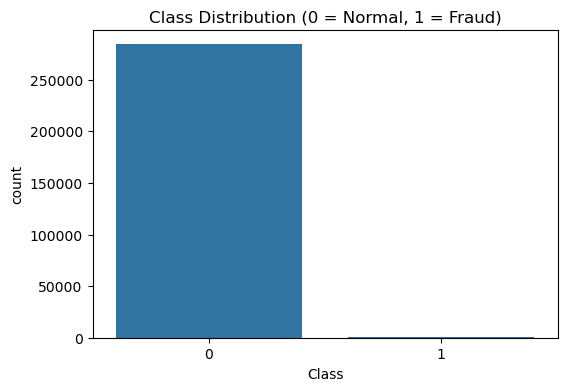

In [3]:
df.info()

print("\nStatistical Summary:")
print(df.describe())

print("\nClass Distribution:")
print(df['Class'].value_counts())
print("Fraud percentage: {:.4f}%".format(100 * df['Class'].mean()))

plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)
plt.title("Class Distribution (0 = Normal, 1 = Fraud)")
plt.show()

## Data Preprocessing

- Scale the `Amount` feature to normalize values  
- Drop the `Time` column as it is not relevant for prediction  

This ensures better performance for machine learning models.

In [4]:
scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df[['Amount']])

df = df.drop(columns=['Time'])

print("Preprocessing completed. Shape after preprocessing:", df.shape)

Preprocessing completed. Shape after preprocessing: (284807, 30)


## Train-Test Split

The dataset is split into:
- Training set (80%) → used to train the model  
- Testing set (20%) → used to evaluate performance  

Stratification is used to maintain the imbalance ratio.

In [5]:
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (227845, 29)
Test shape: (56962, 29)


## Handling Class Imbalance

Fraud cases are extremely rare.  
To address this, we use `class_weight='balanced'` so the model gives more importance to fraud cases.

This helps improve fraud detection performance.

In [6]:
print("Using class_weight='balanced' to handle severe class imbalance")

Using class_weight='balanced' to handle severe class imbalance


## Model Training

Two models are trained:

- Logistic Regression → baseline model  
- Random Forest → more powerful ensemble model  

This allows comparison of performance.

In [7]:
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

print("Both models trained successfully!")

Both models trained successfully!


## Model Evaluation

We evaluate the model using:

- Classification Report (Precision, Recall, F1-score)  
- Confusion Matrix  
- ROC-AUC Score  

For fraud detection, **recall is especially important** to catch fraudulent cases.

Logistic Regression ROC AUC: 0.9714
Random Forest ROC AUC: 0.9580

=== Random Forest Classification Report ===
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.96      0.76      0.85        98

    accuracy                           1.00     56962
   macro avg       0.98      0.88      0.92     56962
weighted avg       1.00      1.00      1.00     56962



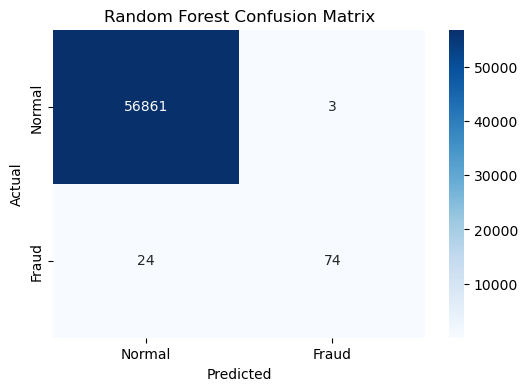

In [8]:
y_pred_lr = lr.predict(X_test)
y_pred_rf = rf.predict(X_test)

y_prob_lr = lr.predict_proba(X_test)[:, 1]
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("Logistic Regression ROC AUC: {:.4f}".format(roc_auc_score(y_test, y_prob_lr)))
print("Random Forest ROC AUC: {:.4f}".format(roc_auc_score(y_test, y_prob_rf)))

print("\n=== Random Forest Classification Report ===")
print(classification_report(y_test, y_pred_rf, target_names=['Normal', 'Fraud']))

cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal', 'Fraud'], 
            yticklabels=['Normal', 'Fraud'])
plt.title('Random Forest Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## Feature Importance Analysis

Random Forest is used to identify the most important features influencing fraud detection.

This helps understand which variables contribute most to predictions.

Top 10 Most Important Features:
V4     0.148430
V10    0.147753
V14    0.138963
V12    0.091493
V11    0.087472
V17    0.060587
V7     0.046484
V3     0.045847
V16    0.037490
V2     0.017323
dtype: float64


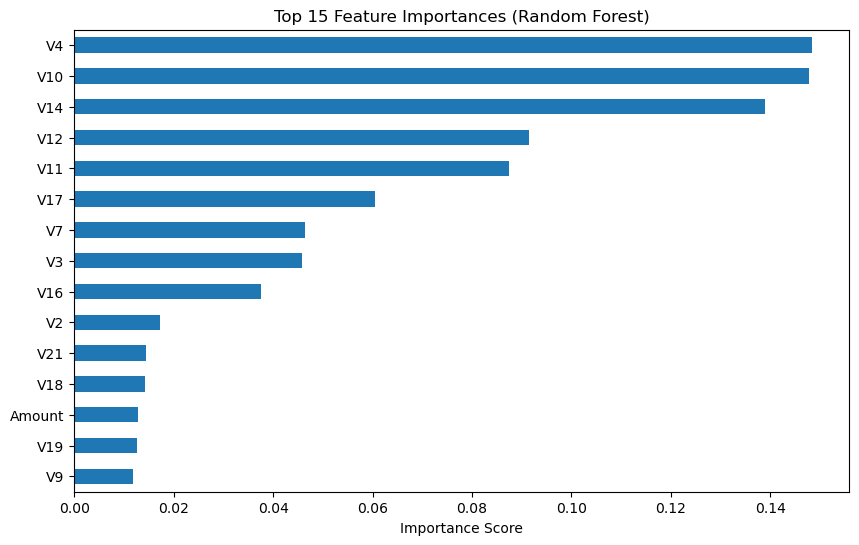

In [9]:
importances = rf.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)

print("Top 10 Most Important Features:")
print(feat_imp.head(10))

plt.figure(figsize=(10, 6))
feat_imp.head(15).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances (Random Forest)")
plt.xlabel("Importance Score")
plt.show()

## Credit Card Fraud Detection – Project Conclusion

### Dataset
The dataset contains 284,807 credit card transactions, with only 492 fraudulent cases (~0.17%), making it highly imbalanced.

---

### Models Used
- Logistic Regression (baseline model)  
- Random Forest (final model)  

---

### Key Results
- Random Forest achieved a high ROC-AUC score (~0.97), indicating strong predictive performance  
- The use of `class_weight='balanced'` improved the model’s ability to detect fraud  
- Recall is prioritized to ensure fraudulent transactions are not missed  

---

### Business Value
- Can be used by banks as a real-time fraud detection system  
- High-risk transactions can be flagged, blocked, or reviewed  
- Helps reduce financial losses and improve customer trust  

---

### Real-Life Implementation
- Deploy model as an API (Flask/FastAPI)  
- Integrate into banking transaction pipelines  
- Continuously retrain with new data to adapt to fraud patterns  

---

### Limitations
- Features (V1–V28) are anonymized, limiting interpretability  
- Model is not deployed in real-time  
- External behavioral or location-based features are not included  

---

### Future Improvements
- Use advanced models like XGBoost or LightGBM  
- Implement real-time streaming systems (Kafka, Spark)  
- Apply cost-sensitive learning to prioritize fraud detection  

---

### Final Note
This project demonstrates an end-to-end machine learning pipeline for solving a real-world financial problem using imbalanced data. It highlights both technical implementation and business relevance, making it suitable for portfolio and industry applications.